## High-Resolution Methods (Metode Resolusi Tinggi)

Metode yang telah kita gunakan sebelumnya (metode upwind dan metode Lax-Friedrichs) bersifat disipatif. Artinya, seiring waktu, solusi yang dihasilkan menjadi semakin “kabur” atau melebar, terutama pada bagian yang tajam seperti shock (diskontinuitas).

Selain itu, kedua metode tersebut hanya memiliki akurasi orde satu (first order accuracy). Ini berarti:

Jika kita memperkecil $Δt$ dan $Δx$ menjadi setengahnya,
Maka error hanya berkurang sekitar setengahnya juga.

Jadi, metode ini kurang efisien untuk mendapatkan hasil yang sangat akurat.
Kabar baiknya: kita bisa membuat metode yang lebih baik.

### Reducing Diffusion (Mengurangi Difusi / Pelebaran Solusi)

Langkah pertama untuk meningkatkan akurasi adalah menggunakan pendekatan yang lebih baik untuk fungsi $q(x)$ di setiap sel (grid).

Sebelumnya:

Kita menganggap q konstan di setiap sel (piecewise constant).

Sekarang:

Kita gunakan pendekatan linear di setiap sel (piecewise linear).

#### 1. Pendekatan Linear

Kita mulai dari ide dasar aproksimasi Taylor orde 1:

$$
q(x)≈q(x_i)+q′(x_i)(x−x_i)
$$

Penjelasan langkah:
- Fungsi $q(x)$ dikembangkan di sekitar titik tengah sel $x_i$
$q(x_i)$ diganti dengan nilai numerik $ Q_i^n $ 
Turunan $q′(x_i)$ kita aproksimasi sebagai slope $σ_i^n$

Maka diperoleh:
$$
q(x)=Q_i^n + σ_i^n (x−x_i)
$$

Penjelasan 

- $q(x)$ → nilai fungsi kontinu di posisi $x$  
- $Q_i^n$ → nilai rata-rata di sel ke-$i$ pada waktu ke-$n$  
- $\sigma_i^n$ → kemiringan (*slope*) di sel ke-$i$  
- $x_i$ → titik tengah sel  
- $(x - x_i)$ → jarak dari pusat sel

#### 2. Menentukan Slope $\sigma_i^n$

Mulai dari definisi turunan:

$$
q'(x) = \frac{dq}{dx}
$$

a. Forward difference (maju)

$$
q'(x_i) \approx \frac{Q_{i+1}^n - Q_i^n}{\Delta x}
$$

b. Backward difference (mundur)

$$
q'(x_i) \approx \frac{Q_i^n - Q_{i-1}^n}{\Delta x}
$$

c. Rata-rata (central difference)

$$
q'(x_i) \approx \frac{1}{2} \left(
\frac{Q_{i+1}^n - Q_i^n}{\Delta x}
+
\frac{Q_i^n - Q_{i-1}^n}{\Delta x}
\right)
$$

Sederhanakan

$$
q'(x_i) \approx \frac{Q_{i+1}^n - Q_{i-1}^n}{2\Delta x}
$$

Maka:

$$
\sigma_i^n = \frac{Q_{i+1}^n - Q_{i-1}^n}{2\Delta x}
$$

Penjelasan

- $Q_{i+1}^n$ → nilai di sel kanan  
- $Q_{i-1}^n$ → nilai di sel kiri  
- $\Delta x$ → lebar sel/grid  
- $\sigma_i^n$ → perkiraan turunan di titik tengah

#### 3. Nilai di Batas Sel (Cell Interface)

Kita ingin tahu nilai di:

kiri → $x_{i-1/2}$  
kanan → $x_{i+1/2}$  

##### Langkah 1: Posisi batas sel

$$
x_{i \pm 1/2} = x_i \pm \frac{\Delta x}{2}
$$

Penjelasan  
$x_i$ → titik tengah  
$\Delta x/2$ → setengah panjang sel  

Jadi batas sel = setengah langkah dari pusat.

##### Langkah 2: Substitusi ke fungsi linear

Gunakan:

$$
q(x) = Q_i^n + \sigma_i^n (x - x_i)
$$

a. Batas kiri $(i - 1/2)$

Substitusi:

$$
x = x_i - \frac{\Delta x}{2}
$$

$$
q_{i-1/2} = Q_i^n + \sigma_i^n \left(-\frac{\Delta x}{2}\right)
$$

Hasil akhir

$$
q_{i-1/2} = Q_i^n - \sigma_i^n \frac{\Delta x}{2}
$$

Penjelasan   
- $q_{i-1/2}$ → nilai di batas kiri sel  
- tanda minus → karena bergerak ke kiri  

b. Batas kanan $(i + 1/2)$

Substitusi:

$$
x = x_i + \frac{\Delta x}{2}
$$

$$
q_{i+1/2} = Q_i^n + \sigma_i^n \left(\frac{\Delta x}{2}\right)
$$

Hasil akhir

$$
q_{i+1/2} = Q_i^n + \sigma_i^n \frac{\Delta x}{2}
$$

Penjelasan simbol  
- $q_{i+1/2}$ → nilai di batas kanan sel  
- tanda plus → karena bergerak ke kanan

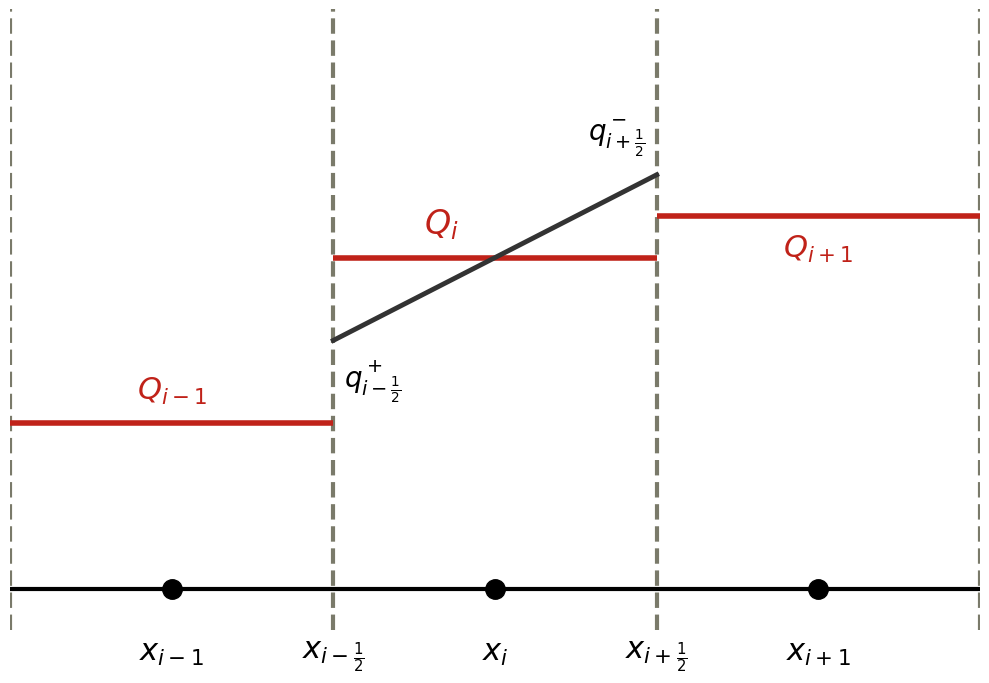

In [8]:
import matplotlib.pyplot as plt                 # Mengimpor library matplotlib untuk plotting

# Membuat figure (kanvas) dan axis (area gambar)
fig, ax = plt.subplots(figsize=(10, 7))         # Ukuran gambar 10x7 inci

# Koordinat sumbu X untuk batas sel (interface) dan titik tengah sel
x_interfaces = [0, 3, 6, 9]                     # Posisi batas antar sel
x_centers = [1.5, 4.5, 7.5]                     # Posisi titik tengah tiap sel

# Nilai rata-rata sel (Q) dan nilai rekonstruksi di batas (q)
Q = [3, 5, 5.5]                                 # Nilai rata-rata untuk sel i-1, i, i+1
q_plus = 4.0                                    # Nilai rekonstruksi di sisi kanan batas kiri (i-1/2)
q_minus = 6.0                                   # Nilai rekonstruksi di sisi kiri batas kanan (i+1/2)

# Menggambar garis vertikal putus-putus sebagai batas sel
for x in x_interfaces:  # Loop setiap posisi batas
    ax.vlines(x=x, ymin=0.5, ymax=8, color='#7A7A6A', linestyle='--', linewidth=3)  # Garis batas sel

# Menggambar garis horizontal sebagai sumbu dasar (baseline)
ax.hlines(y=1, xmin=0, xmax=9, color='black', linewidth=3)  # Garis horizontal di bawah

# Menambahkan titik hitam di tengah sel
ax.plot(x_centers, [1, 1, 1], 'ko', markersize=14)  # Titik pusat sel

# Menggambar nilai rata-rata sel sebagai garis horizontal merah
ax.hlines(y=Q[0], xmin=x_interfaces[0], xmax=x_interfaces[1], color='#C02219', linewidth=4)  # Sel i-1
ax.hlines(y=Q[1], xmin=x_interfaces[1], xmax=x_interfaces[2], color='#C02219', linewidth=4)  # Sel i
ax.hlines(y=Q[2], xmin=x_interfaces[2], xmax=x_interfaces[3], color='#C02219', linewidth=4)  # Sel i+1

# Menggambar garis rekonstruksi linier (garis miring) di sel ke-i
ax.plot([x_interfaces[1], x_interfaces[2]], [q_plus, q_minus], color='#333333', linewidth=3.5)  # Garis slope

# Label untuk titik tengah sel (sumbu X)
labels_x = [r'$x_{i-1}$', r'$x_i$', r'$x_{i+1}$']  # Label posisi tengah sel
labels_interfaces = [r'$x_{i-\frac{1}{2}}$', r'$x_{i+\frac{1}{2}}$']  # Label batas sel

# Menambahkan teks label pada titik tengah sel
for i, x in enumerate(x_centers):  # Loop tiap titik tengah
    ax.text(x, 0.4, labels_x[i], fontsize=22, ha='center', va='top')  # Tampilkan label

# Menambahkan label untuk batas sel (interface)
ax.text(x_interfaces[1], 0.4, labels_interfaces[0], fontsize=22, ha='center', va='top')  # Label i-1/2
ax.text(x_interfaces[2], 0.4, labels_interfaces[1], fontsize=22, ha='center', va='top')  # Label i+1/2

# Menambahkan label nilai rata-rata sel (Q)
ax.text(1.5, Q[0] + 0.2, r'$Q_{i-1}$', fontsize=22, color='#C02219', ha='center', va='bottom')  # Label Q i-1
ax.text(4.0, Q[1] + 0.2, r'$Q_i$', fontsize=24, color='#C02219', ha='center', va='bottom')     # Label Q i
ax.text(7.5, Q[2] - 0.2, r'$Q_{i+1}$', fontsize=22, color='#C02219', ha='center', va='top')    # Label Q i+1

# Menambahkan label nilai rekonstruksi q di batas sel
ax.text(3.1, q_plus - 0.2, r'$q^+_{i-\frac{1}{2}}$', fontsize=20, color='black', ha='left', va='top')   # Label q plus
ax.text(5.9, q_minus + 0.2, r'$q^-_{i+\frac{1}{2}}$', fontsize=20, color='black', ha='right', va='bottom')  # Label q minus

# Mengatur batas tampilan sumbu
ax.set_xlim(0, 9)  # Batas sumbu X
ax.set_ylim(0, 8)  # Batas sumbu Y

# Menyembunyikan axis default 
ax.axis('off')  # Menghilangkan garis dan angka axis

# Mengatur layout agar tidak terpotong
plt.tight_layout()  # Merapikan layout

# Menampilkan hasil gambar
plt.show()  # Menampilkan plot

### Flux Approximation (Pendekatan Flux)

Kita akan menggunakan nilai di batas sel (*interface values*) untuk menghitung flux, berdasarkan metode Lax-Friedrichs.

##### 1. Rumus Flux di Batas Sel
Metode Lax-Friedrichs klasik:

$$
F =
\frac{1}{2}
\left(f(q_L) + f(q_R)\right)
-
\frac{\alpha}{2}
(q_R - q_L)
$$

Penyesuaian ke notasi grid  

$q_L = q_{i-1/2}^-$ → dari sel kiri  
$q_R = q_{i-1/2}^+$ → dari sel kanan  
$\alpha = \frac{\Delta t}{\Delta x}$  

Maka diperoleh:

$$
F_{i-1/2} =
\frac{1}{2}
\left(
f(q_{i-1/2}^-) + f(q_{i-1/2}^+)
-
\frac{\Delta t}{\Delta x}
(q_{i-1/2}^+ - q_{i-1/2}^-)
\right)
$$

Penjelasan simbol  
- $F_{i-1/2}$ → flux di batas kiri sel  
- $f(q)$ → fungsi flux (misalnya $f(q)=uq$ pada adveksi)  
- $q^-, q^+$ → nilai dari kiri & kanan interface  
- $\Delta x$ → ukuran grid  
- $\Delta t$ → langkah waktu  

##### 2. Update Waktu (Runge-Kutta Orde 2)

Untuk membuat metode akurat dalam waktu, digunakan Runge-Kutta orde 2 (RK2).


Langkah 1 (Predictor)

Ini berasal dari bentuk dasar konservasi:

$$
\frac{dQ_i}{dt} =
-
\frac{1}{\Delta x}
(F_{i+1/2} - F_{i-1/2})
$$

Diskretisasi Euler maju  

$$
Q_i^{n+1} =
Q_i^n
+
\Delta t \cdot \frac{dQ_i}{dt}
$$

Substitusi:

$$
Q_i^* =
Q_i^n
-
\frac{\Delta t}{\Delta x}
(F_{i+1/2}^n - F_{i-1/2}^n)
$$

Penjelasan simbol  
- $Q_i^*$ → nilai sementara (prediksi)  
- $F_{i+1/2}, F_{i-1/2}$ → flux kanan & kiri  
- selisih flux → perubahan isi sel  

Langkah 2 (Corrector)

Metode RK2 (Heun method):

$$
Q^{n+1} =
\frac{1}{2}(Q^n + Q^*)
+
\frac{1}{2} \Delta t \cdot f(Q^*)
$$

ubstitusi bentuk konservasi  

Karena:

$$
f(Q) =
-
\frac{1}{\Delta x}
(F_{i+1/2} - F_{i-1/2})
$$

Maka didapat bentuk akhir:

$$
Q_i^{n+1} =
\frac{1}{2} Q_i^n
+
\frac{1}{2}
\left(
Q_i^*
-
\frac{\Delta t}{\Delta x}
(F_{i+1/2}^* - F_{i-1/2}^*)
\right)
$$

Penjelasan simbol  
- $Q_i^{n+1}$ → nilai akhir di waktu berikutnya  
- $Q_i^*$ → hasil prediksi  
- $F^*$ → flux dihitung dari nilai prediksi  


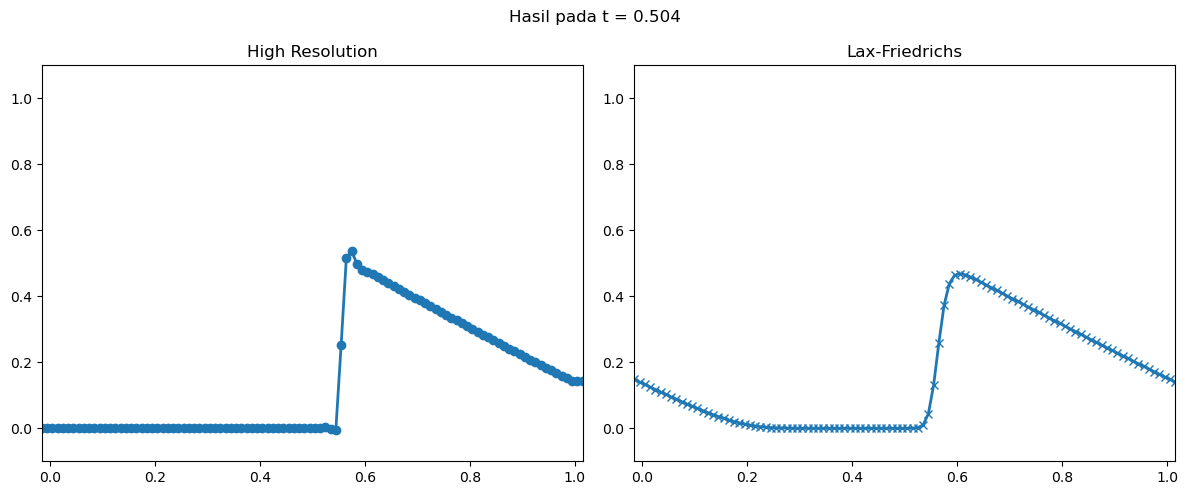

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def f(q):
    return q * (1.0 - q)

m = 100
delta_x = 1.0 / float(m)
x = np.arange(-3.0 * delta_x / 2.0, 1.0 + 5.0 * delta_x / 2.0, delta_x)

t = 0.
T = 0.5
CFL = 0.9
delta_t = CFL * delta_x

Q_HR = 0.9 * np.exp(-100.0 * (x - 0.5)**2)
Q_new_HR = np.zeros(m + 4)
Q_star = np.zeros(m + 4)
sigma = np.zeros(m + 4)
F = np.zeros(m + 4)

Q_LF = Q_HR.copy()
Q_new_LF = np.zeros(m + 4)

# 👉 Buat 1 figure dengan 2 subplot (sebelahan)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

while t < T:
    
    # ===== High Resolution =====
    sigma[1:-1]  = (Q_HR[2:] - Q_HR[:-2]) / (2.0 * delta_x)
    q_plus  = Q_HR[1:-1] - sigma[1:-1] * delta_x / 2.0
    q_minus = Q_HR[:-2] + sigma[:-2]  * delta_x / 2.0
    F[1:-1] = 0.5 * (f(q_plus) + f(q_minus) - delta_x / delta_t * (q_plus - q_minus))
    
    Q_star[2:-2] = Q_HR[2:-2] - delta_t / delta_x * (F[3:-1] - F[2:-2])
    Q_star[0:2] = Q_star[2]
    Q_star[-2:] = Q_star[-3]
    
    sigma[1:-1]  = (Q_star[2:] - Q_star[:-2]) / (2.0 * delta_x)
    q_plus  = Q_star[1:-1] - sigma[1:-1] * delta_x / 2.0
    q_minus = Q_star[:-2] + sigma[:-2]  * delta_x / 2.0
    F[1:-1] = 0.5 * (f(q_plus) + f(q_minus) - delta_x / delta_t * (q_plus - q_minus))
    
    Q_new_HR[2:-2] = 0.5 * Q_HR[2:-2] + 0.5 * (Q_star[2:-2] - delta_t / delta_x * (F[3:-1] - F[2:-2]))
        
    Q_HR = Q_new_HR.copy()
    Q_HR[0:2] = Q_HR[2]
    Q_HR[-2:] = Q_HR[-3]
    
    # ===== Lax-Friedrichs =====
    Q_new_LF[1:-1] = 0.5 * (Q_LF[:-2] + Q_LF[2:]) - 0.5 * delta_t / delta_x * (
        Q_LF[2:] * (1.0 - Q_LF[2:]) - Q_LF[:-2] * (1.0 - Q_LF[:-2])
    )
    
    Q_LF = Q_new_LF.copy()
    Q_LF[0] = Q_LF[-2]
    Q_LF[-1] = Q_LF[1]
    
    t += delta_t

# ===== Plot akhir (sebelahan) =====

# kiri: High Resolution
axes[0].plot(x, Q_HR, 'o-', linewidth=2)
axes[0].set_title("High Resolution")
axes[0].set_xlim((x[0], x[-1]))
axes[0].set_ylim((-0.1, 1.1))

# kanan: Lax-Friedrichs
axes[1].plot(x, Q_LF, 'x-', linewidth=2)
axes[1].set_title("Lax-Friedrichs")
axes[1].set_xlim((x[0], x[-1]))
axes[1].set_ylim((-0.1, 1.1))

plt.suptitle(f"Hasil pada t = {t:.3f}")
plt.tight_layout()
plt.show()

Permasalahan pada High-Resolution Methods

Gelombang kejut (*shock wave*) sekarang terlihat jauh lebih tajam, tetapi kita mendapatkan masalah baru. Apakah kamu melihat adanya cekungan kecil (*dip*) di belakang shock? Jika diperhatikan dengan lebih teliti, ternyata solusi di sana bahkan bernilai negatif! Jelas hal ini tidak masuk akal, karena misalnya jika $q$ menyatakan kepadatan mobil, maka kepadatan tidak mungkin bernilai negatif. Selain itu, solusi juga seharusnya tidak mengalami penurunan seperti itu di belakang shock, dan juga tidak seharusnya memiliki tonjolan aneh di bagian depan shock. Lalu, apa yang harus kita lakukan?

## Slope Limiting (Pembatas Kemiringan)

Osilasi (gelombang tidak stabil) yang muncul pada solusi bukan hanya masalah metode tertentu saja.  

Faktanya:
Semua metode orde dua (atau lebih tinggi) yang menghitung nilai di interface ($q^\pm_{i+1/2}$) sebagai fungsi linear dari rata-rata sel akan menghasilkan osilasi.  

Hal ini dikenal sebagai:

Teorema Godunov (Godunov's Theorem)

Untuk menghindari osilasi, kita tidak boleh menggunakan kemiringan (slope) linear biasa.

Sebagai gantinya:
Gunakan slope yang bersifat nonlinear

Definisi selisih (difference)

Misalkan:

$$
\Delta Q_{i-1/2} = Q_i - Q_{i-1}
$$

$$
\Delta Q_{i+1/2} = Q_{i+1} - Q_i
$$

Definisi slope dengan minmod

Kemiringan di sel $i$ didefinisikan sebagai:

$$
\sigma_i = \frac{\text{minmod}(\Delta Q_{i-1/2}, \Delta Q_{i+1/2})}{\Delta x}
$$

fungsi minmod

Fungsi minmod memilih slope "paling aman" (tidak menyebabkan osilasi):

$$
\sigma_i =
\begin{cases}
\min(\Delta Q_{i-1/2}, \Delta Q_{i+1/2})/\Delta x 
& \text{jika keduanya positif} \\

\max(\Delta Q_{i-1/2}, \Delta Q_{i+1/2})/\Delta x 
& \text{jika keduanya negatif} \\

0 
& \text{jika tanda berbeda}
\end{cases}
$$

Penjelasan tiap kasus

##### 1. Kedua slope positif
Artinya data naik (monoton naik)

- Pilih yang **lebih kecil**
- Supaya tidak terlalu curam

##### 2. Kedua slope negatif
Artinya data turun

- Pilih yang **lebih kecil secara absolut** (lebih dekat ke nol)
- Supaya tidak terlalu tajam

##### 3. Tanda berbeda
Artinya ada puncak atau lembah (kemungkinan osilasi)

- Set slope = 0
- Ini membuat solusi menjadi **datar (flat)** di titik tersebut

## Local Lax-Friedrichs Flux

Flux Lax-Friedrichs menjamin solusi stabil, tetapi menghasilkan difusi yang besar di seluruh domain (solusi jadi terlalu halus/blur).

Padahal:  
Kita sebenarnya tidak selalu membutuhkan difusi sebesar itu di semua tempat.

Solusinya adalah Local Lax-Friedrichs flux, yaitu variasi yang:

menggunakan kecepatan karakteristik lokal  
sehingga jumlah difusi disesuaikan di setiap titik  

Hasilnya:

lebih akurat dibanding Lax-Friedrichs biasa  

##### 1. Rumus Local Lax-Friedrichs

Persamaan:

$$
F_{i-1/2} =
\frac{1}{2}
\left(
f(q_{i-1/2}^-) + f(q_{i-1/2}^+)
-
\alpha_{i-1/2}
\frac{\Delta t}{\Delta x}
(q_{i-1/2}^+ - q_{i-1/2}^-)
\right)
$$

Penurunan dari Lax-Friedrichs Biasa

Rumus awal (global):

$$
F =
\frac{1}{2}
\left(f(q_L) + f(q_R)\right)
-
\frac{\alpha}{2}
(q_R - q_L)
$$

Modifikasi utama  

Pada metode lama:

$\alpha$ = konstanta global (sama di semua tempat)  

Pada metode lokal:

$\alpha \rightarrow \alpha_{i-1/2}$  
nilainya berbeda di setiap interface  

Maka:

$$
F_{i-1/2} =
\frac{1}{2}
\left(f(q^-) + f(q^+)\right)
-
\frac{1}{2}
\alpha_{i-1/2}
(q^+ - q^-)
$$

Disesuaikan dengan skala numerik  

Karena dalam skema sebelumnya:

$$
\alpha \sim \frac{\Delta t}{\Delta x}
$$

Maka muncul bentuk:

$$
\alpha_{i-1/2} \frac{\Delta t}{\Delta x}
$$

Penjelasan simbol  
- $F_{i-1/2}$ → flux di batas sel  
- $q_{i-1/2}^-$ → nilai dari kiri  
- $q_{i-1/2}^+$ → nilai dari kanan  
- $f(q)$ → fungsi flux  
- $\Delta x$ → ukuran grid  
- $\Delta t$ → langkah waktu  
- $\alpha_{i-1/2}$ → kecepatan karakteristik lokal  

##### 2. Penentuan $\alpha_{i-1/2}$

Persamaan:

$$
\alpha_{i-1/2} =
\min\left(
|f'(q_{i-1/2}^-)|,
|f'(q_{i-1/2}^+)|
\right)
$$

Penurunan / Asal-usul

Dalam persamaan konservasi:

$$
q_t + f(q)_x = 0
$$

Kecepatan gelombang diberikan oleh:

$$
a = f'(q)
$$

Interpretasi  

$f'(q)$ = kecepatan karakteristik  
menunjukkan seberapa cepat informasi merambat  

Kenapa pakai nilai absolut?  

$|f'(q)|$  

Karena yang penting adalah:

besar kecepatan, bukan arah  

Kenapa ambil nilai minimum?  

$$
\alpha_{i-1/2} =
\min(|f'(q^-)|, |f'(q^+)|)
$$

Artinya:

kita ambil kecepatan terkecil  
sehingga difusi tidak terlalu besar  

Penjelasan simbol  
- $f'(q)$ → turunan fungsi flux  
- $|f'(q)|$ → besar kecepatan gelombang  

##### Exercise (Latihan)

Modifikasi metode orde dua sebelumnya dengan:

- Menggunakan **minmod slope**
- Menggunakan **Local Lax-Friedrichs flux**
- Menggunakan metode waktu **RK2 (predictor–corrector)**

###### 1. Fungsi Minmod

Gunakan bentuk tanpa `if` agar bisa dipakai pada array:

$$
\text{minmod}(a,b)
= \frac{1}{2}(\text{sign}(a) + \text{sign}(b)) \cdot \min(|a|,|b|)
$$

##### Implementasi Python

```python
import numpy as np

def minmod(a, b):
    return 0.5 * (np.sign(a) + np.sign(b)) * np.minimum(np.abs(a), np.abs(b))
```

##### 2. Fungsi Flux

Contoh: persamaan konservasi sederhana

$$
f(q) = \frac{1}{2} q^2
$$

```python
def flux(q):
    return 0.5 * q**2

def dflux(q):
    return q  # turunan f'(q)
```

###### 3. Rekonstruksi (Minmod Slope)

Hitung slope:

$$
\sigma_i = \text{minmod}\left(
\frac{Q_i - Q_{i-1}}{\Delta x},
\frac{Q_{i+1} - Q_i}{\Delta x}
\right)
$$

```python
def compute_slope(Q, dx):
    dql = (Q - np.roll(Q, 1)) / dx
    dqr = (np.roll(Q, -1) - Q) / dx
    return minmod(dql, dqr)
```

###### 4. Rekonstruksi Nilai di Interface

$$
q^-_{i+1/2} = Q_i + \frac{1}{2} \sigma_i \Delta x
$$

$$
q^+_{i-1/2} = Q_i - \frac{1}{2} \sigma_i \Delta x
$$

```python
def reconstruct(Q, slope, dx):
    qL = Q + 0.5 * slope * dx   # kiri
    qR = Q - 0.5 * slope * dx   # kanan
    return qL, qR
```

###### 5. Local Lax-Friedrichs Flux

$$
F_{i-1/2} =
\frac{1}{2}\left(
f(q^-) + f(q^+) -
\alpha (q^+ - q^-)
\right)
$$

dengan:

$$
\alpha = \min(|f'(q^-)|, |f'(q^+)|)
$$

```python
def llf_flux(qL, qR):
    fL = flux(qL)
    fR = flux(qR)
    
    alpha = np.minimum(np.abs(dflux(qL)), np.abs(dflux(qR)))
    
    return 0.5 * (fL + fR - alpha * (qR - qL))
```

###### 6. Update (RK2)

###### Step 1: Hitung flux

```python
def compute_rhs(Q, dx):
    slope = compute_slope(Q, dx)
    qL, qR = reconstruct(Q, slope, dx)
    
    # shift untuk interface
    qR_shift = np.roll(qR, -1)
    
    F = llf_flux(qL, qR_shift)
    
    return -(F - np.roll(F, 1)) / dx
```

###### Step 2: RK2 (predictor-corrector)

```python
def step_RK2(Q, dt, dx):
    # Predictor
    Q1 = Q + dt * compute_rhs(Q, dx)
    
    # Corrector
    Q2 = 0.5 * (Q + Q1 + dt * compute_rhs(Q1, dx))
    
    return Q2
```

###### 7. Contoh Simulasi

```python
# Grid
nx = 100
x = np.linspace(0, 1, nx)
dx = x[1] - x[0]

# Initial condition (shock-like)
Q = np.where(x < 0.5, 1.0, 0.0)

# Waktu
dt = 0.5 * dx
nt = 100

# Time stepping
for n in range(nt):
    Q = step_RK2(Q, dt, dx)
```

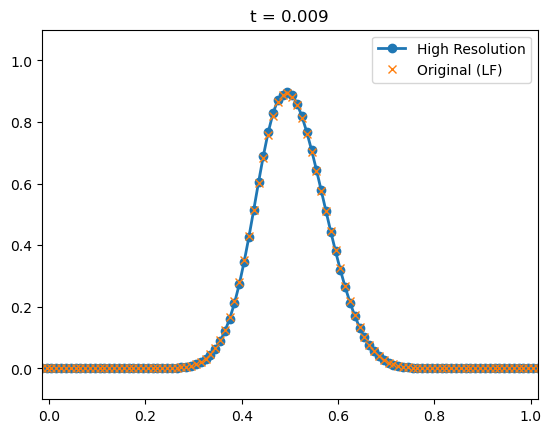

In [11]:
import numpy
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

def minmod(a, b):
    return (numpy.sign(a) + numpy.sign(b)) / 2.0 * numpy.minimum(numpy.abs(a), numpy.abs(b))

def f(q):
    return q * (1.0 - q)

def f_prime(q):
    return 1.0 - 2.0 * q

m = 100
delta_x = 1.0 / float(m)
x = numpy.arange(-3.0 * delta_x / 2.0, 1.0 + 5.0 * delta_x / 2.0, delta_x)

t = 0.  # Waktu awal
T = 0.5 # Waktu akhir
CFL = 0.9
delta_t = CFL * delta_x  # Time step

Q = 0.9 * numpy.exp(-100.0 * (x - 0.5)**2)
Q_new = numpy.zeros(m + 4)
Q_star = numpy.zeros(m + 4)
sigma = numpy.zeros(m + 4)
F = numpy.zeros(m + 4)

Q_LF = 0.9 * numpy.exp(-100.0 * (x - 0.5)**2)
Q_new_LF = numpy.zeros(m + 4)

# Untuk menyimpan history data animasi
history_Q = []
history_Q_LF = []
history_t = []

while t < T:
    # --- Metode High-Resolution ---
    # Tahap 1 (Prediktor)
    sigma[1:-1]  = minmod(Q[1:-1] - Q[:-2], Q[2:] - Q[1:-1]) / delta_x
    Q_plus  = Q[1:-1] - sigma[1:-1] * delta_x / 2.0
    Q_minus = Q[:-2] + sigma[:-2]  * delta_x / 2.0
    alpha = numpy.minimum(numpy.abs(f_prime(Q_minus)), numpy.abs(f_prime(Q_plus)))
    
    F[1:-1] = 0.5 * (f(Q_plus) + f(Q_minus) - alpha * (Q_plus - Q_minus))
    
    Q_star[2:-2] = Q[2:-2] - delta_t / delta_x * (F[3:-1] - F[2:-2])
    Q_star[0:2] = Q_star[2]
    Q_star[-2:] = Q_star[-3]
    
    # Tahap 2 (Korektor) - menggunakan minmod juga agar TVD
    sigma[1:-1] = minmod(Q_star[1:-1] - Q_star[:-2], Q_star[2:] - Q_star[1:-1]) / delta_x
    q_plus  = Q_star[1:-1] - sigma[1:-1] * delta_x / 2.0
    q_minus = Q_star[:-2] + sigma[:-2]  * delta_x / 2.0
    
    # Perbaikan typo: menggunakan q_plus dan q_minus (huruf kecil)
    F[1:-1] = 0.5 * (f(q_plus) + f(q_minus) - alpha * (q_plus - q_minus))
    
    Q_new[2:-2] = 0.5 * Q[2:-2] + 0.5 * (Q_star[2:-2] - delta_t / delta_x * (F[3:-1] - F[2:-2]))
        
    Q = Q_new.copy()
    Q[0:2] = Q[2]
    Q[-2:] = Q[-3]
        
    # --- Metode Lax-Friedrichs (Original) ---
    Q_new_LF[1:-1] = 0.5 * (Q_LF[:-2] + Q_LF[2:]) - 0.5 * delta_t / delta_x * (f(Q_LF[2:]) - f(Q_LF[:-2]))
    
    Q_LF = Q_new_LF.copy()
    # Menyamakan kondisi batas dengan High-Res
    Q_LF[0] = Q_LF[1]
    Q_LF[-1] = Q_LF[-2]
    
    # Update waktu hanya satu kali!
    t += delta_t
    
    # Simpan data untuk dianimasikan nanti
    history_Q.append(Q.copy())
    history_Q_LF.append(Q_LF.copy())
    history_t.append(t)

# --- Proses Animasi Standar Matplotlib ---
fig, ax = plt.subplots()
ax.set_xlim((x[0], x[-1]))
ax.set_ylim((-0.1, 1.1))

line1, = ax.plot([], [], 'o-', linewidth=2, label="High Resolution")
line2, = ax.plot([], [], 'x', linewidth=2, label="Original (LF)")
title = ax.set_title('')
ax.legend()

def animate(i):
    line1.set_data(x, history_Q[i])
    line2.set_data(x, history_Q_LF[i])
    title.set_text(f't = {history_t[i]:.3f}')
    return line1, line2, title

ani = FuncAnimation(fig, animate, frames=len(history_t), interval=50, blit=True)
plt.show()

Seperti yang bisa kamu lihat, metode ini mampu menjaga shock (diskontinuitas) tetap cukup tajam dan juga menghindari munculnya nilai solusi negatif.

Metode ini termasuk dalam kelas skema MUSCL (Monotonic Upstream-centered Schemes for Conservation Laws) dan telah terbukti dapat mencegah terjadinya osilasi (gelombang tidak stabil).

## High-Order Methods (Metode Orde Tinggi)

Seperti metode yang telah kita buat sebelumnya, sebagian besar metode dengan akurasi lebih tinggi dari orde satu terdiri dari tiga komponen utama:

##### 1. Reconstruction (Rekonstruksi)

Rekonstruksi adalah proses untuk menghitung nilai di batas sel:

$q_{i-1/2}^-, q_{i-1/2}^+$  

dari nilai rata-rata sel:

$Q_i$  

$Q_i \rightarrow q_{i-1/2}^-, q_{i-1/2}^+$  

Penjelasan simbol  
- $Q_i$ → nilai rata-rata di sel ke-$i$  
- $q^-$ → nilai dari sisi kiri interface  
- $q^+$ → nilai dari sisi kanan interface  

Kenapa perlu rekonstruksi?  

Karena:

data awal hanya diketahui di tengah sel  
tapi flux butuh nilai di batas sel  

Masalah  

Jika rekonstruksi terlalu “bebas”:

bisa muncul osilasi (wiggles) di dekat shock  

##### 2. Numerical Flux (Flux Numerik)

Flux numerik adalah cara menghitung:

$F_{i-1/2}$  

menggunakan nilai hasil rekonstruksi.

Hubungan Dasar  

$$
F_{i-1/2} = F(q_{i-1/2}^-, q_{i-1/2}^+)
$$

Penjelasan  

$F_{i-1/2}$ → flux di batas sel  

bergantung pada dua sisi:  
kiri $q^-$  
kanan $q^+$  

Ide Riemann Solver  

Masalah Riemann:

$$
q(x,0)=
\begin{cases}
q_L, & x<0 \\
q_R, & x>0
\end{cases}
$$

Makna  

Kita punya dua kondisi berbeda (kiri & kanan)  
solver menghitung bagaimana gelombang berkembang  

Hasilnya:

flux yang lebih akurat secara fisik  

---

##### 3. Time Integrator (Integrasi Waktu)

Digunakan untuk menghitung perkembangan solusi terhadap waktu:

$Q_i^n \rightarrow Q_i^{n+1}$  

Bentuk dasar persamaan  

$$
\frac{dQ_i}{dt} =
-
\frac{1}{\Delta x}
(F_{i+1/2} - F_{i-1/2})
$$

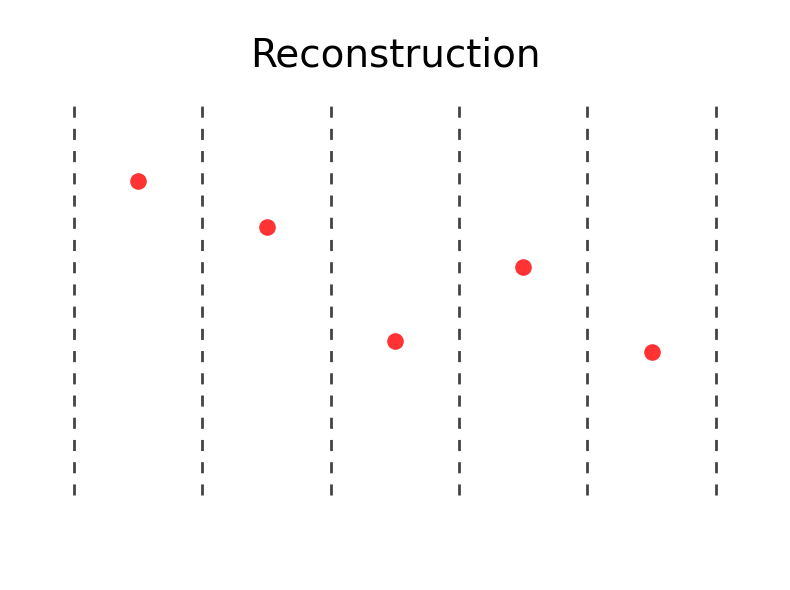

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Membuat figure dan axis
fig, ax = plt.subplots(figsize=(8, 6))

# Menambahkan judul teks "Reconstruction" di bagian atas tengah
ax.text(0.5, 0.92, 'Reconstruction', fontsize=28, ha='center', va='center', transform=ax.transAxes, color='black')

# Menghapus sumbu dan kotak plot agar latar belakang bersih
ax.axis('off')

# Mengatur batas sumbu untuk menempatkan elemen dengan benar dalam sel
ax.set_xlim(-0.5, 5.5)
ax.set_ylim(0, 1)

# Menghambar garis vertikal putus-putus (dashed lines)
# Ada 6 garis, memisahkan 5 kolom (sel)
x_lines = np.arange(0, 6)
for x in x_lines:
    # Menggambar garis vertikal dari y=0.15 hingga y=0.85
    # dashes=(4, 4) menentukan panjang putus-putus dan jarak antar putus-putus
    ax.plot([x, x], [0.15, 0.85], color='#444444', linestyle='--', dashes=(4, 4), linewidth=2)

# Menghambar titik merah (red dots)
# Ada 5 titik, satu di setiap sel (di tengah-tengah antar garis putus-putus)
x_dots = np.arange(0.5, 5.5)

# Posisi y diestimasi dari gambar asli: [tinggi, menengah-tinggi, rendah, menengah, rendah]
y_dots = [0.70, 0.62, 0.42, 0.55, 0.40] 

# Menggunakan ax.scatter untuk menggambar titik. s adalah ukuran marker.
ax.scatter(x_dots, y_dots, color='#FF3333', s=120, zorder=3) # zorder memastikan titik di depan garis

# Menampilkan plot
plt.tight_layout()
plt.show()

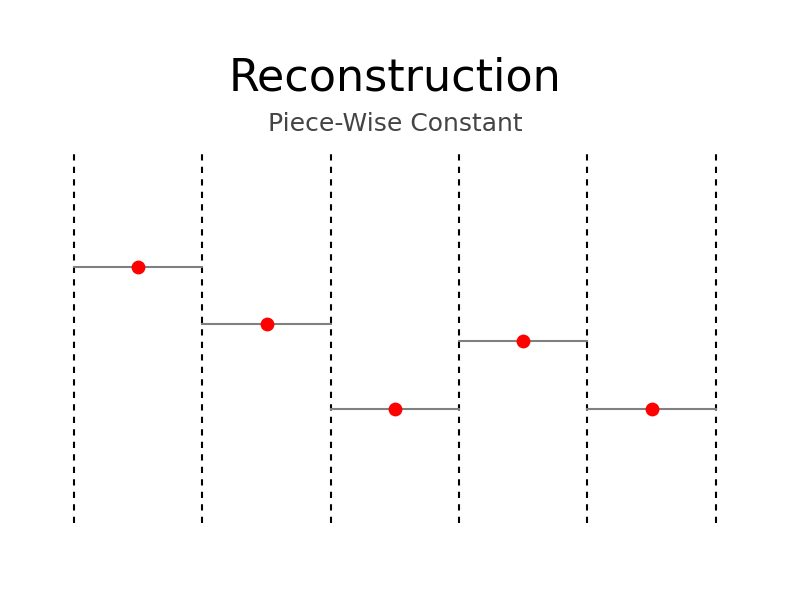

In [13]:
import matplotlib.pyplot as plt                # Mengimpor modul pyplot dari matplotlib untuk membuat plot/grafik
import numpy as np                             # Mengimpor modul numpy untuk operasi numerik dan pembuatan array

# Membuat figure dan axis
fig, ax = plt.subplots(figsize=(8, 6)) # Membuat area gambar (figure) dan sumbunya (axis) dengan ukuran 8x6 inci

# Menambahkan judul "Reconstruction" dan subjudul "Piece-Wise Constant"
ax.text(0.5, 0.88, 'Reconstruction', fontsize=32, ha='center', va='center', transform=ax.transAxes, color='black') # Menambahkan teks judul utama di posisi tengah atas
ax.text(0.5, 0.80, 'Piece-Wise Constant', fontsize=18, ha='center', va='center', transform=ax.transAxes, color='#444444') # Menambahkan teks subjudul berwarna abu-abu gelap di bawah judul

# Menghapus sumbu dan kotak plot agar mirip dengan gambar asli
ax.axis('off')                                  # Menyembunyikan semua garis tepi kotak dan angka pada sumbu x maupun y

# Mengatur batas sumbu
ax.set_xlim(-0.5, 5.5) # Menentukan batas koordinat sumbu x dari -0.5 sampai 5.5 agar gambar pas di tengah
ax.set_ylim(0, 1) # Menentukan batas koordinat sumbu y dari 0 sampai 1

# Posisi X untuk batas sel (garis putus-putus) dan titik tengah sel
x_edges = np.arange(0, 6) # Membuat array posisi batas sel: [0, 1, 2, 3, 4, 5]
x_centers = np.arange(0.5, 5.5) # Membuat array posisi tengah sel: [0.5, 1.5, 2.5, 3.5, 4.5]

# Perkiraan tinggi nilai Y untuk masing-masing sel berdasarkan gambar
y_vals = [0.55, 0.45, 0.30, 0.42, 0.30] # Menyimpan 5 nilai tinggi/koordinat y untuk titik dan garis konstan

# 1. Menggambar garis vertikal putus-putus (pembatas sel)
for x in x_edges: # Memulai perulangan untuk setiap posisi batas vertikal di x_edges
    ax.plot([x, x], [0.1, 0.75], color='black', linestyle='--', dashes=(3, 3), linewidth=1.5) # Menggambar garis vertikal putus-putus dari bawah (y=0.1) ke atas (y=0.75)

# 2. Menggambar garis horizontal abu-abu (piece-wise constant)
for i in range(len(y_vals)): # Memulai perulangan sebanyak jumlah sel (5 kali)
    ax.plot([x_edges[i], x_edges[i+1]], [y_vals[i], y_vals[i]], color='gray', linewidth=1.5) # Menggambar garis horizontal solid dari batas kiri ke kanan pada ketinggian konstan y_vals[i]

# 3. Menggambar titik merah di tengah-tengah
ax.scatter(x_centers, y_vals, color='red', s=80, zorder=3) # Menggambar titik-titik merah di posisi (x_centers, y_vals). zorder=3 memastikan titik ada di paling depan/atas garis

# Menyesuaikan tata letak dan menampilkan plot
plt.tight_layout() # Merapikan tata letak gambar secara otomatis agar tidak ada teks yang terpotong
plt.show() # Memunculkan jendela (window) hasil gambar grafik ke layar

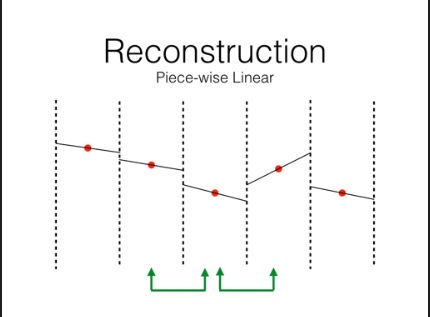

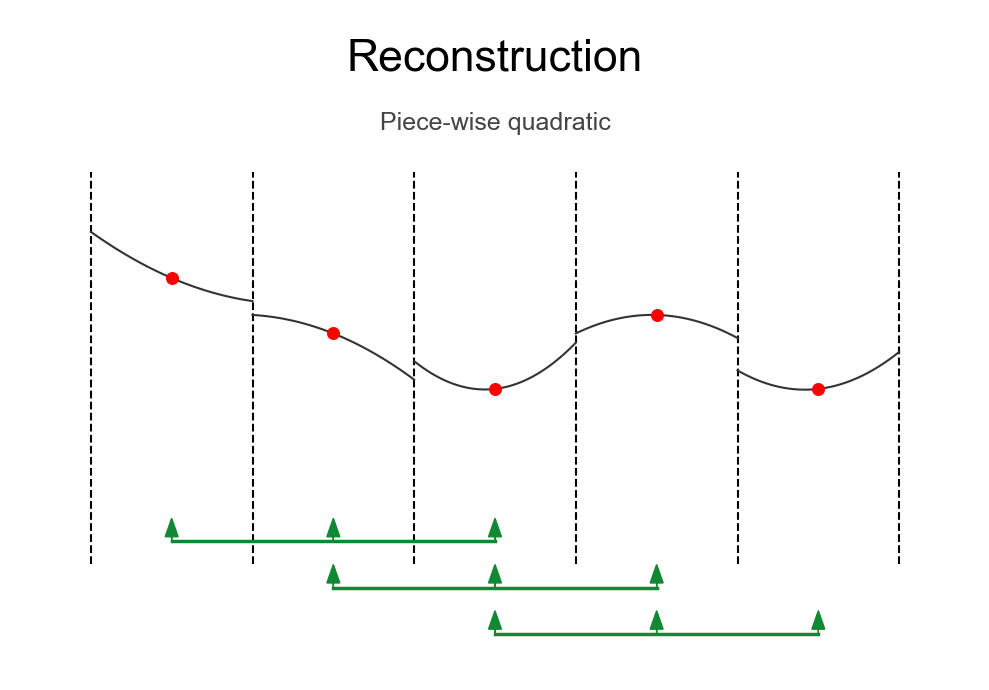

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Menyiapkan Figure
fig, ax = plt.subplots(figsize=(10, 7))
ax.set_facecolor('white')
fig.set_facecolor('white')

# 2. Menambahkan Judul dan Subjudul
ax.text(2.5, 0.95, 'Reconstruction', fontsize=32, ha='center', va='bottom', color='black')
ax.text(2.5, 0.88, 'Piece-wise quadratic', fontsize=18, ha='center', va='top', color='#444444')

# 3. Menggambar Batas Sel (Grid Putus-putus)
x_grid = np.arange(0, 6)
ax.vlines(x=x_grid, ymin=-0.1, ymax=0.75, color='black', linestyle='--', linewidth=1.5, zorder=1)

# 4. Mendefinisikan Titik untuk Kurva Kuadratik
# Kita mendefinisikan 3 titik (kiri, tengah, kanan) untuk setiap sel agar bisa membentuk kurva parabola
# Titik tengah (indeks ke-1 di tiap sub-list) akan menjadi titik merah
curves_x = [
    [0.0, 0.5, 1.0],
    [1.0, 1.5, 2.0],
    [2.0, 2.5, 3.0],
    [3.0, 3.5, 4.0],
    [4.0, 4.5, 5.0]
]

curves_y = [
    [0.62, 0.52, 0.47], # Sel 1: cekung ke atas, turun
    [0.44, 0.40, 0.30], # Sel 2: cekung ke bawah, turun
    [0.34, 0.28, 0.38], # Sel 3: cekung ke atas, nilai minimum di tengah
    [0.40, 0.44, 0.39], # Sel 4: cekung ke bawah, nilai maksimum di tengah
    [0.32, 0.28, 0.36]  # Sel 5: cekung ke atas, naik
]

# 5. Menggambar Kurva Kuadratik dan Titik Merah
x_red = []
y_red = []

for i in range(5):
    # Mengumpulkan koordinat titik merah (selalu titik tengah dari data curves_x/y)
    x_red.append(curves_x[i][1])
    y_red.append(curves_y[i][1])
    
    # Membuat polinomial derajat 2 (kuadratik) dari 3 titik
    p = np.polyfit(curves_x[i], curves_y[i], 2)
    
    # Menghasilkan banyak titik untuk menggambar kurva yang mulus
    xx = np.linspace(curves_x[i][0], curves_x[i][2], 50)
    yy = np.polyval(p, xx)
    
    # Menggambar kurva hitam
    ax.plot(xx, yy, color='#333333', linewidth=1.5, zorder=2)

# Menggambar titik merah di atas kurva
ax.scatter(x_red, y_red, color='red', s=70, zorder=3)

# 6. Fungsi Khusus untuk Menggambar Stencil (Panah Hijau Bawah)
def draw_stencil(ax, x_start, x_end, y_level, arrow_x_positions):
    """Menggambar garis horizontal dengan panah-panah vertikal ke atas."""
    # Garis horizontal penyambung
    ax.plot([x_start, x_end], [y_level, y_level], color='#118833', linewidth=2.5)
    
    # Panah vertikal
    for x_pos in arrow_x_positions:
        # ax.arrow(x, y, dx, dy)
        ax.arrow(x_pos, y_level, 0, 0.05, 
                 head_width=0.08, head_length=0.04, 
                 fc='#118833', ec='#118833', 
                 length_includes_head=True, zorder=4)

# Menggambar ketiga stencil (mewakili skema rekonstruksi polinomial 3-sel)
# Stencil 1: Meliputi sel 1, 2, 3
draw_stencil(ax, 0.5, 2.5, -0.05, [0.5, 1.5, 2.5])
# Stencil 2: Meliputi sel 2, 3, 4
draw_stencil(ax, 1.5, 3.5, -0.15, [1.5, 2.5, 3.5])
# Stencil 3: Meliputi sel 3, 4, 5
draw_stencil(ax, 2.5, 4.5, -0.25, [2.5, 3.5, 4.5])

# 7. Penyesuaian Tampilan Akhir
ax.set_axis_off()          # Sembunyikan sumbu X dan Y
ax.set_xlim(-0.5, 5.5)     # Margin kiri kanan
ax.set_ylim(-0.35, 1.1)    # Margin atas bawah untuk memberi ruang bagi panah dan judul

plt.tight_layout()
plt.show()

Ada banyak cara berbeda untuk melakukan rekonstruksi dan pembatasan (limiting) pada solusi, jadi cobalah beberapa metode.

Untuk melakukan ini, kamu memerlukan instalasi Clawpack. Silakan lihat halaman resmi Clawpack untuk petunjuk instalasinya:
http://www.clawpack.org

In [ ]:
# ===== IMPORT =====
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation

from clawpack import pyclaw
from clawpack import riemann

# ===== RIEMANN SOLVER =====
riemann_solver = riemann.advection_1D_py.advection_1D

# ===== SOLVER =====
solver = pyclaw.ClawSolver1D(riemann_solver)
solver.kernel_language = "Python"

# Boundary condition (periodic)
solver.bc_lower[0] = pyclaw.BC.periodic
solver.bc_upper[0] = pyclaw.BC.periodic

# Pilih limiter (4 = MC)
solver.limiters = 4
solver.order = 2

limiter_name = ["None", "minmod", "superbee", "Van Leer", "MC", "Beam-Warming", "Fromm",
                "Albada 2", "Albada 3", "Van Leer with Klein sharpening"]

# ===== DOMAIN =====
x = pyclaw.Dimension(0.0, 1.0, 100, name='x')
domain = pyclaw.Domain(x)
state = pyclaw.State(domain, solver.num_eqn)

# ===== DATA MASALAH =====
state.problem_data['u'] = 1.0

# ===== KONDISI AWAL =====
xc = state.grid.x.centers
beta = 100
gamma = 0
x0 = 0.75

state.q[0, :] = np.exp(-beta * (xc - x0)**2) * np.cos(gamma * (xc - x0))
state.q[0, :] += 1.0 * ((0.2 < xc) & (xc < 0.4))

# ===== CONTROLLER =====
claw = pyclaw.Controller()
claw.keep_copy = True
claw.solution = pyclaw.Solution(state, domain)
claw.solver = solver

claw.num_output_times = 30
claw.tfinal = 1.0   

# ===== RUN =====
claw.run()

# ===== AMBIL DATA =====
frames = claw.frames
times = [frame.t for frame in frames]

# ===== PLOT & ANIMASI =====
fig, ax = plt.subplots(figsize=(8, 5))

line, = ax.plot([], [], 'o-', lw=2, label="Numerical")
line0, = ax.plot(xc, frames[0].q[0, :], 'k--', label="Initial")

ax.set_xlim(0, 1)
ax.set_ylim(-0.2, 1.2)
ax.legend()

def init():
    line.set_data([], [])
    return (line,)

def update(frame):
    line.set_data(xc, frames[frame].q[0, :])
    ax.set_title(f"Limiter = {limiter_name[solver.limiters]}, t = {times[frame]:.2f}")
    return (line,)

ani = animation.FuncAnimation(
    fig, update,
    frames=len(frames),
    init_func=init,
    blit=True,
    interval=100
)

plt.show()

ModuleNotFoundError: No module named 'clawpack'

## Fluid Dynamics (Dinamika Fluida)

Sebagai contoh yang lebih kompleks dari sistem hukum kekekalan (*conservation laws*), sekarang kita akan mempelajari persamaan Euler pada dinamika gas yang dapat dimampatkan (*compressible gas dynamics*).

Persamaan ini terdiri dari hukum kekekalan untuk:
- massa  
- momentum  
- energi  

#### Mass Conservation (Kekekalan Massa)

Kita menggunakan:

$\rho(x,t)$ untuk menyatakan densitas fluida (massa per volume)  
$u(x,t)$ untuk menyatakan kecepatan fluida  

Maka persamaan kekekalan massa diberikan oleh persamaan kontinuitas (*continuity equation*) yang sudah dibahas sebelumnya:

Bentuk dasar

$$
\rho_t + (\rho u)_x = 0
$$

Penjelasan simbol  
- $\rho(x,t)$ → densitas (massa per satuan volume)  
- $u(x,t)$ → kecepatan fluida  
- $\rho u$ → flux massa (aliran massa)  
- $\rho_t$ → perubahan massa terhadap waktu  
- $(\rho u)_x$ → perubahan aliran massa terhadap ruang  

Penurunan Persamaan (Derivasi)

##### Langkah 1: Ambil sebuah kontrol volume

Misalkan kita ambil interval kecil:

$$
[x, x+\Delta x]
$$

Total massa di dalamnya:

$$
\text{massa} = \int_x^{x+\Delta x} \rho(x,t)\,dx
$$

##### Langkah 2: Perubahan massa terhadap waktu

$$
\frac{d}{dt} \int_x^{x+\Delta x} \rho(x,t)\,dx
$$

##### Langkah 3: Flux masuk dan keluar

Flux masuk di kiri: $(\rho u)(x)$  
Flux keluar di kanan: $(\rho u)(x+\Delta x)$  

Hukum konservasi:

Perubahan massa = masuk − keluar

$$
\frac{d}{dt} \int_x^{x+\Delta x} \rho \, dx
=
- \left[(\rho u)(x+\Delta x) - (\rho u)(x)\right]
$$

##### Langkah 4: Ubah ke bentuk diferensial

Gunakan turunan:

$$
\frac{(\rho u)(x+\Delta x) - (\rho u)(x)}{\Delta x}
\approx (\rho u)_x
$$

Bagi dengan $\Delta x$ dan ambil limit $\Delta x \rightarrow 0$:

$$
\rho_t + (\rho u)_x = 0
$$

#### Momentum Conservation (Kekekalan Momentum)

Momentum fluida diberikan oleh hasil kali antara densitas dan kecepatan, yaitu:

$$
\rho u$$

Flux momentum memiliki dua komponen.  
Yang pertama adalah:

Momentum dibawa oleh aliran fluida, sama seperti massa.  

Flux ini diberikan oleh:

$$
\rho u^2
$$

1. Apa itu Momentum?

$$
\text{Momentum} = \rho u
$$

Penjelasan simbol  
- $\rho$ → densitas (massa per volume)  
- $u$ → kecepatan  
- $\rho u$ → momentum per satuan volume  

2. Flux Momentum

massa mengalir dengan flux:  
$$\rho u
$$  

setiap massa membawa momentum $u$  

Maka:

$$
\text{flux momentum} = (\text{massa flux}) \times (\text{kecepatan})
$$

$$
= (\rho u) \times u
$$

$$
= \rho u^2
$$

Penjelasan simbol  
- $\rho u$ → aliran massa  
- $u$ → momentum per massa  
- $\rho u^2$ → aliran momentum  

#### Energy Conservation (Kekekalan Energi)

Energi fluida memiliki dua komponen:

energi internal $\rho e$  
energi kinetik $\frac{1}{2} \rho u^2$  

Sehingga energi total:

$$
E = \rho e + \frac{1}{2} \rho u^2
$$

- $E$ → energi total per satuan volume  
- $\rho$ → densitas fluida  
- $e$ → energi internal per satuan massa  
- $u$ → kecepatan fluida  

Seperti pada momentum, flux energi terdiri dari:

transport oleh aliran: $Eu$  
transport akibat tekanan: $pu$  

Sehingga persamaan kekekalan energi:

$$
E_t + (u(E+p))_x = 0
$$

- $E_t$ → perubahan energi terhadap waktu  
- $(u(E+p))_x$ → perubahan flux energi terhadap ruang  

##### Flux Energi

$$
\text{Energy flux} = u(E + p)
$$

Flux energi = jumlah energi yang mengalir per satuan waktu  

Terdiri dari dua bagian:

##### (1) Transport oleh aliran

$Eu$  

energi dibawa oleh fluida yang bergerak  

##### (2) Transport karena tekanan

$pu$  

tekanan melakukan kerja pada fluida  
ini menambah/mentransfer energi  

Gabungan

$$
Eu + pu = u(E + p)
$$

#### Equation of State (Persamaan Keadaan)

Kita memiliki 4 variabel tak diketahui:

- densitas ($\rho$)  
- momentum ($\rho u$)  
- energi ($E$)  
- tekanan ($p$)  

Namun hanya ada 3 persamaan konservasi:

- massa  
- momentum  
- energi  

Artinya: sistem belum tertutup (belum bisa diselesaikan)

Solusi  

Kita butuh 1 persamaan tambahan  
yang disebut:

persamaan keadaan (*equation of state*)  

Fungsi persamaan keadaan  

Menghubungkan:

$p \leftrightarrow \rho, e$  

yaitu hubungan antara:

- tekanan  
- densitas  
- energi internal  

---

##### 1. Persamaan Gas Ideal

$$
p = \rho e (\gamma - 1)
$$

- $p$ → tekanan  
- $\rho$ → densitas  
- $e$ → energi internal per massa  
- $\gamma$ → rasio kalor spesifik  

##### 2. Apa itu $\gamma$?

$$
\gamma = \frac{c_p}{c_v}
$$

Penjelasan  

$c_p$ → kalor jenis pada tekanan konstan  
$c_v$ → kalor jenis pada volume konstan  

Nilai umum  

udara: $\gamma \approx 1.4$  
gas monoatomik: $\gamma \approx 1.67$  

##### 3. Makna Fisik Persamaan

$$
p = \rho e (\gamma - 1)
$$

Artinya:

tekanan berasal dari energi internal molekul  
semakin besar energi internal → tekanan meningkat  

#### Full Equations (Persamaan Lengkap Euler)

Kita dapat menuliskan tiga hukum kekekalan (massa, momentum, energi) sebagai satu sistem persamaan:

$$
q_t + f(q)_x = 0
$$

dengan mendefinisikan:

$$
q =
\begin{pmatrix}
\rho \\
\rho u \\
E
\end{pmatrix},
\quad
f(q) =
\begin{pmatrix}
\rho u \\
\rho u^2 + p \\
u(E+p)
\end{pmatrix}
$$

##### 1. Bentuk Umum Sistem Konservasi

$$
q_t + f(q)_x = 0
$$

- $q$ → vektor variabel konservatif  
- $f(q)$ → vektor flux  
- $q_t$ → perubahan terhadap waktu  
- $f(q)_x$ → perubahan flux terhadap ruang  

Semua hukum kekekalan bisa ditulis dalam bentuk yang sama:

perubahan = selisih flux  

##### 2. Vektor Variabel $q$

$$
q =
\begin{pmatrix}
\rho \\
\rho u \\
E
\end{pmatrix}
$$

Isi dari $q$:

- $\rho$ → massa (densitas)  
- $\rho u$ → momentum  
- $E$ → energi total  

Kenapa disebut "variabel konservatif"?  

Karena semuanya memenuhi bentuk:

$$
(\text{quantity})_t + (\text{flux})_x = 0
$$

##### 3. Vektor Flux $f(q)$

$$
f(q) =
\begin{pmatrix}
\rho u \\
\rho u^2 + p \\
u(E+p)
\end{pmatrix}
$$

Penjelasan tiap komponen  

##### 1. Flux massa

$$
\rho u
$$  

massa yang mengalir  

##### 2. Flux momentum

$$
\rho u^2 + p
$$  

terdiri dari:

$\rho u^2$ → transport oleh aliran  
$p$ → efek tekanan  

##### 3. Flux energi

$$
u(E+p)
$$  

terdiri dari:

$Eu$ → energi dibawa aliran  
$pu$ → kerja oleh tekanan  

##### 4. Hubungan dengan 3 Persamaan Awal

Sistem ini setara dengan:

##### (1) Massa

$$
\rho_t + (\rho u)_x = 0
$$

##### (2) Momentum

$$
(\rho u)_t + (\rho u^2 + p)_x = 0
$$

##### (3) Energi

$$
E_t + (u(E+p))_x = 0
$$

Dalam tiga dimensi, persamaan memiliki bentuk yang mirip.  
Kita memiliki dua komponen kecepatan tambahan, yaitu $v$ dan $w$, beserta flux-nya.

Selain itu, kita juga harus memperhitungkan aliran (flux) pada arah:

$x$, $y$, $z$

Sehingga sistem lengkap dapat ditulis sebagai:

#### Persamaan utama 3D

$$
q_t + f(q)_x + g(q)_y + h(q)_z = 0
$$

- $q$ → vektor variabel konservatif  
- $f(q)$ → flux arah $x$  
- $g(q)$ → flux arah $y$  
- $h(q)$ → flux arah $z$  

perubahan dalam waktu =  
flux masuk/keluar dari semua arah (x, y, z)

##### 1. Vektor Variabel $q$

$$
q =
\begin{pmatrix}
\rho \\
\rho u \\
\rho v \\
\rho w \\
E
\end{pmatrix}
$$

Isi dari $q$:

- $\rho$ → densitas  
- $\rho u$ → momentum arah $x$  
- $\rho v$ → momentum arah $y$  
- $\rho w$ → momentum arah $z$  
- $E$ → energi total  

##### 2. Flux arah $x$ → $f(q)$

$$
f(q) =
\begin{pmatrix}
\rho u \\
\rho u^2 + p \\
\rho uv \\
\rho uw \\
u(E+p)
\end{pmatrix}
$$

- $\rho u$ → aliran massa arah $x$  
- $\rho u^2 + p$ → momentum $x$  
- $\rho uv$ → momentum $y$ terbawa arah $x$  
- $\rho uw$ → momentum $z$ terbawa arah $x$  
- $u(E+p)$ → energi  

##### 3. Flux arah $y$ → $g(q)$

$$
g(q) =
\begin{pmatrix}
\rho v \\
\rho uv \\
\rho v^2 + p \\
\rho vw \\
v(E+p)
\end{pmatrix}
$$

- $\rho v$ → aliran massa arah $y$  
- $\rho uv$ → momentum $x$ terbawa arah $y$  
- $\rho v^2 + p$ → momentum $y$  
- $\rho vw$ → momentum $z$ terbawa arah $y$  
- $v(E+p)$ → energi  

##### 4. Flux arah $z$ → $h(q)$

$$
h(q) =
\begin{pmatrix}
\rho w \\
\rho uw \\
\rho vw \\
\rho w^2 + p \\
w(E+p)
\end{pmatrix}
$$

- $\rho w$ → aliran massa arah $z$  
- $\rho uw$ → momentum $x$ terbawa arah $z$  
- $\rho vw$ → momentum $y$ terbawa arah $z$  
- $\rho w^2 + p$ → momentum $z$  
- $w(E+p)$ → energi  

## Menyelesaikan Persamaan Euler

Persamaan ini dapat diselesaikan dengan cara yang mirip seperti yang digunakan pada kasus adveksi dan aliran lalu lintas.  

Namun, seperti yang bisa diduga, perhitungan fluks (flux) menjadi jauh lebih rumit karena sekarang kita memiliki:
- 3 persamaan (untuk 1D), atau  
- 5 persamaan (untuk kasus yang lebih kompleks, misalnya 3D)  

Selain itu, bentuk ekspresi fluks juga menjadi lebih kompleks.

#### Penjelasan konsep

- Persamaan Euler adalah sistem persamaan diferensial parsial (PDE) yang menggambarkan:
  - konservasi massa  
  - konservasi momentum  
  - konservasi energi  

#### Kenapa lebih rumit?

Pada kasus sederhana (seperti adveksi):
- Hanya ada 1 persamaan  
- Fluks sederhana  

Sedangkan pada Persamaan Euler:
- Ada beberapa variabel sekaligus (misalnya: densitas, kecepatan, energi)  
- Fluks bergantung pada semua variabel tersebut  

Jadi:
- Perhitungan menjadi lebih kompleks  
- Implementasi dari nol cukup panjang dan teknis  

#### Menggunakan PyClaw

Membuat solver Persamaan Euler dari awal sebenarnya menarik, tetapi akan memakan waktu cukup lama.  

Untuk menghemat waktu, kita akan menggunakan package:

- PyClaw → bagian dari software Clawpack
- Clawpack = *Conservation LAWs PACKage*  

#### Fungsi PyClaw

PyClaw memungkinkan kita untuk:
- Menyusun model dengan cepat  
- Menyelesaikan masalah berbasis PDE hiperbolik  
- Menghindari implementasi numerik yang rumit dari nol  

In [ ]:
from clawpack import pyclaw
from clawpack import riemann

## Menyiapkan Sebuah Masalah (Setting up a Problem)

Untuk menyelesaikan suatu masalah numerik (misalnya PDE), kita perlu menyiapkan beberapa komponen utama:

#### 1. Domain

Domain adalah wilayah tempat kita menyelesaikan masalah.

Contoh:
- 1D: $x \in [0,1]$
- 2D: bidang persegi
- 3D: volume ruang

Makna:
- Menentukan di mana solusi dihitung

#### 2. Solution (Solusi)

Solution adalah variabel yang menyimpan data solusi.

- Di awal:
  - berisi kondisi awal (initial condition) 
- Setelah simulasi:
  - berisi hasil akhir solusi

#### 3. Solver

Solver adalah bagian utama yang melakukan perhitungan.

Tugas solver:
- Menyelesaikan persamaan (misalnya PDE)
- Mengupdate solusi dari waktu ke waktu

Biasanya solver membutuhkan:
- Persamaan yang akan diselesaikan
- Metode numerik (FEM, finite volume, dll)
- Kondisi batas

##### 4. Controller

Controller mengatur jalannya simulasi.

Tugasnya:
- Menjalankan loop waktu
- Mengatur output (file/grafik)
- Mengontrol kapan simulasi berhenti

Sekarang kita mulai dengan membuat **controller** dan menentukan **waktu akhir simulasi (final time)**.

In [ ]:
claw = pyclaw.Controller()
claw.tfinal = 0.1                    # Waktu akhir simulasi

claw.keep_copy = True          # Menyimpan data solusi di memori untuk plotting
claw.output_format = None      # Tidak menyimpan data solusi ke file
claw.num_output_times = 50     # Menghasilkan 50 frame output

Metode yang digunakan untuk menghitung fluks di antara setiap pasangan sel disebut sebagai *Riemann solver*. Dengan menentukan Riemann solver yang digunakan, kita sebenarnya sekaligus menentukan sistem persamaan diferensial parsial (PDE) yang ingin diselesaikan. Sejauh ini, kita hanya menggunakan Riemann solver aproksimasi yang sangat sederhana. Namun, Clawpack menyediakan Riemann solver yang jauh lebih canggih untuk berbagai sistem hiperbolik.

Untuk melihat daftar Riemann solver yang tersedia di PyClaw, letakkan kursor di akhir baris pada kotak kode, lalu tekan tombol **Tab** (autocompletion). Akan muncul daftar pilihan solver yang tersedia. Solver yang memiliki akhiran “$_py$” ditulis menggunakan Python murni, sedangkan yang lainnya ditulis dalam bahasa Fortran dan dihubungkan ke Python menggunakan *f2py*, sehingga biasanya memiliki performa yang lebih cepat.

In [ ]:
dir(riemann)

Kita akan mulai dengan masalah sederhana satu dimensi (1D), dengan menggunakan Riemann solver `riemann.euler_with_efix_1D`.

In [ ]:
riemann_solver = riemann.euler_with_efix_1D  # Memilih Riemann solver untuk persamaan Euler 1D dengan entropy fix
claw.solver = pyclaw.ClawSolver1D(riemann_solver)  # Menginisialisasi solver 1D dan menghubungkannya dengan Riemann solver

Kita juga perlu menentukan kondisi batas. Pada kasus ini, kita akan menggunakan kondisi batas ekstrapolasi (*extrapolation boundary conditions*), sehingga gelombang dapat keluar dari domain tanpa pantulan.

In [ ]:
claw.solver.all_bcs = pyclaw.BC.extrap  # Menggunakan boundary condition ekstrapolasi, yaitu nilai di batas diambil dari nilai sel terdekat di dalam domain

## Domain Masalah

Selanjutnya, kita perlu menentukan domain dan grid. Kita akan menyelesaikan masalah pada interval satuan $[0,1]$ menggunakan 100 sel grid. Perlu diperhatikan bahwa setiap argumen pada konstruktor Domain harus diberikan dalam bentuk tuple.

In [ ]:
domain = pyclaw.Domain((0.,), (1.,), (100,))  # Membuat domain 1D dari 0 hingga 1 dengan 100 sel/grid

## Solusi Awal

Selanjutnya, kita membuat objek solusi (*solution*) yang terhubung dengan controller dan didefinisikan pada domain yang telah kita tentukan sebelumnya.

In [ ]:
claw.solution = pyclaw.Solution(claw.solver.num_eqn, domain)  # Membuat objek solusi dengan jumlah persamaan dan domain yang telah ditentukan

In [ ]:
claw.solution = pyclaw.Solution(3, domain)  # Membuat objek solusi dengan 3 persamaan pada domain yang telah ditentukan

Data awal ditentukan dalam sebuah array bernama `solution.q`. Nilai densitas disimpan pada `q[0,:]`, momentum pada `q[1,:]`, dan energi pada `q[2,:]`.

In [ ]:
x = domain.grid.x.centers           # Mengambil posisi pusat setiap sel grid (cell centers)

gam = 1.4                           # Rasio panas jenis (gamma), biasanya untuk gas ideal

rho_left = 1.0                      # Densitas di sisi kiri domain
rho_right = 0.125                   # Densitas di sisi kanan domain

p_left = 1.0                        # Tekanan di sisi kiri
p_right = 0.1                       # Tekanan di sisi kanan

# Mengisi densitas awal:
# Jika x < 0.5 → gunakan rho_left
# Jika x >= 0.5 → gunakan rho_right
claw.solution.q[0,:] = (x < 0.5)*rho_left + (x >= 0.5)*rho_right  

# Momentum awal di seluruh domain = 0 (fluida diam)
claw.solution.q[1,:] = 0.           

# Menghitung energi awal:
# E = p / (gamma - 1)
# Menggunakan kondisi kiri dan kanan seperti densitas
claw.solution.q[2,:] = ((x < 0.5)*p_left + (x >= 0.5)*p_right) / (gam - 1.0)

# Membuat figure untuk plotting
fig = plt.figure()                  

# Menambahkan subplot (1 baris, 1 kolom, plot pertama)
axes = fig.add_subplot(1, 1, 1)     

# Plot densitas terhadap posisi x
axes.plot(x, claw.solution.q[0,:], '-o')  

# Mengatur batas sumbu x dari 0 sampai 1
axes.set_xlim((0.0, 1.0))           

# Mengatur batas sumbu y
axes.set_ylim((-0.1, 1.1))          

Masalah ini dikenal sebagai *Sod shock-tube*. Secara fisik, ini merepresentasikan sebuah tabung yang dipisahkan oleh sekat tipis menjadi dua bagian: satu bagian dengan tekanan dan densitas tinggi, dan bagian lainnya dengan tekanan serta densitas rendah. Ketika sekat tersebut tiba-tiba dihilangkan, kedua kondisi ini akan berinteraksi dan menghasilkan gelombang kejut (*shock*), gelombang ekspansi (*rarefaction*), dan diskontinuitas kontak.

Selanjutnya, kita perlu menentukan nilai $\gamma$, yaitu rasio panas jenis (specific heat ratio).

In [ ]:
problem_data = claw.solution.problem_data
problem_data['gamma'] = 1.4   # Menetapkan nilai rasio panas spesifik (γ)
problem_data['gamma1'] = 0.4  # Menetapkan γ - 1 (biasanya digunakan dalam perhitungan persamaan Euler)

Terakhir, kita jalankan simulasi untuk melihat bagaimana solusi berkembang seiring waktu.

In [ ]:
claw.run()  # Menjalankan simulasi

## Plotting

Sekarang kita akan memplot hasil simulasi, yang disimpan dalam sebuah list bernama `claw.frames`. Untuk memplot satu frame, kita dapat menggunakan matplotlib dengan cara yang sederhana.

In [ ]:
figs = []
for frame in claw.frames:
    figs.append(plt.figure())  # Membuat figure baru untuk setiap frame
    axes = figs[-1].add_subplot(1, 1, 1)  # Menambahkan subplot
    axes.plot(x, frame.q[0, :], 'o-', linewidth=2)  # Plot data (misalnya variabel pertama)
    axes.set_xlim((0, 1))  # Mengatur batas sumbu x
    axes.set_ylim((-0.2, 1.2))  # Mengatur batas sumbu y
    plt.close(figs[-1])  # Menutup figure agar tidak langsung ditampilkan

# Menganimasikan hasil solusi
images = animation.make_images(figs)  # Mengubah figure menjadi kumpulan gambar
animation.JSAnimate_images(images)  # Menampilkan animasi dalam bentuk interaktif

## Gelombang (Waves)

Dalam solusi yang dihasilkan, terdapat tiga jenis gelombang yang dapat diamati:

1. **Shock wave (gelombang kejut)** yang bergerak cepat ke arah kanan akibat fluida berdensitas rendah mengalami kompresi.
2. **Rarefaction wave (gelombang ekspansi)** yang bergerak ke arah kiri ketika fluida berdensitas tinggi mengembang.
3. **Contact discontinuity (diskontinuitas kontak)** yang bergerak lebih lambat ke arah kanan. Diskontinuitas ini menunjukkan perubahan densitas yang memisahkan fluida yang awalnya berada di sisi tekanan tinggi dan fluida dari sisi tekanan rendah.

Secara umum, solusi dari setiap masalah Riemann terdiri dari kombinasi ketiga jenis gelombang ini. Dalam persamaan Euler, salah satu gelombang selalu berupa diskontinuitas kontak, sedangkan dua gelombang lainnya bisa berupa shock atau rarefaction, tergantung pada kondisi awal di sisi kiri dan kanan.

## Menggabungkan Semua (Putting it all together)

Untuk memudahkan, seluruh kode dari langkah-langkah sebelumnya untuk menyiapkan dan menjalankan masalah shock tube telah digabungkan di bawah ini. Silakan bereksperimen dengan kode tersebut. Beberapa hal yang bisa kamu coba antara lain:

- Meningkatkan jumlah grid untuk melihat bagaimana solusi semakin mendekati solusi sebenarnya (konvergen). Perhatikan bahwa kode tetap berjalan cukup cepat meskipun jumlah grid diperbesar. Hal ini karena bagian inti dari PyClaw ditulis dalam bahasa Fortran yang sudah dikompilasi, bukan Python.
- Mengubah kondisi awal di sisi kiri dan kanan, atau bahkan membuat kondisi awal yang benar-benar berbeda. Coba lihat apakah kamu bisa menghasilkan solusi dengan dua gelombang kejut (*shock*) atau dua gelombang ekspansi (*rarefaction*). Di sini, intuisi fisika akan sangat membantu.
- Mengubah nilai rasio panas jenis ($\gamma$) untuk melihat pengaruhnya terhadap solusi.
- Mengubah kondisi batas menjadi periodik, sehingga muncul gelombang kejut tambahan yang bergerak ke kiri dari $x = 1$.

In [ ]:
from clawpack import pyclaw
from clawpack import riemann

# Membuat controller utama untuk simulasi
claw = pyclaw.Controller()
claw.tfinal = 0.2  # Waktu akhir simulasi

# Pengaturan output
claw.keep_copy = True       # Menyimpan data solusi di memori (untuk plotting)
claw.output_format = None   # Tidak menyimpan hasil ke file
claw.num_output_times = 50  # Jumlah frame output (50 langkah waktu)

# Memilih Riemann solver untuk persamaan Euler 1D dengan entropy fix
riemann_solver = riemann.euler_with_efix_1D
claw.solver = pyclaw.ClawSolver1D(riemann_solver)  # Inisialisasi solver 1D

# Menetapkan kondisi batas (boundary condition) sebagai ekstrapolasi
claw.solver.all_bcs = pyclaw.BC.extrap

# Membuat domain 1D dari 0 sampai 1 dengan 100 grid
domain = pyclaw.Domain((0.,), (1.,), (100,))
x = domain.grid.x.centers  # Titik tengah setiap sel grid

# Inisialisasi solusi dengan jumlah persamaan dari solver
claw.solution = pyclaw.Solution(claw.solver.num_eqn, domain)

# Parameter gas (ideal gas)
gam = 1.4  # Rasio panas spesifik (gamma)
claw.solution.problem_data['gamma'] = gam
claw.solution.problem_data['gamma1'] = gam - 1.0  # gamma - 1

# Kondisi awal (shock tube / Riemann problem)
rho_left = 1.0; rho_right = 0.125   # Densitas kiri dan kanan
p_left = 1.0; p_right = 0.1         # Tekanan kiri dan kanan

# Mengatur kondisi awal pada domain
claw.solution.q[0, :] = (x < 0.5) * rho_left + (x >= 0.5) * rho_right  # Densitas
claw.solution.q[1, :] = 0.  # Momentum awal (diam)
claw.solution.q[2, :] = ((x < 0.5) * p_left + (x >= 0.5) * p_right) / (gam - 1.0)  # Energi

# Menjalankan simulasi
status = claw.run()

# Visualisasi hasil
figs = []
for frame in claw.frames:
    figs.append(plt.figure())  # Membuat figure untuk tiap waktu
    axes = figs[-1].add_subplot(1, 1, 1)  # Subplot
    axes.plot(x, frame.q[0, :], 'o-', linewidth=2)  # Plot densitas
    axes.set_xlim((0, 1))  # Batas sumbu x
    axes.set_ylim((-0.2, 1.2))  # Batas sumbu y
    plt.close(figs[-1])  # Tutup figure agar tidak langsung tampil

# Membuat animasi dari hasil simulasi
images = animation.make_images(figs)
animation.JSAnimate_images(images)